<a href="https://colab.research.google.com/github/jaswan333/Aviation_ML/blob/main/Airline_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/jaswan333/Aviation_ML.git

fatal: destination path 'Aviation_ML' already exists and is not an empty directory.


In [3]:
%cd Airline-Project

[Errno 2] No such file or directory: 'Airline-Project'
/content


In [4]:
%cd Aviation_ML

/content/Aviation_ML


In [5]:
import pandas as pd

train = pd.read_csv("/content/Aviation_ML/airline_passenger_satisfaction_train.csv")   # or data/train.csv
test = pd.read_csv("/content/Aviation_ML/airline_passenger_satisfaction_test.csv")

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0.1                       103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

In [7]:
train.shape

(103904, 25)

In [8]:
test.shape

(25976, 25)

In [9]:
train.isnull().sum()

,0
Unnamed: 0.1,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0


In [10]:
train.isnull().sum()[train.isnull().sum() > 0]

,0
Arrival Delay in Minutes,310


In [11]:
null_percent = (train.isnull().sum() / len(train)) * 100
null_percent[null_percent > 0]

,0
Arrival Delay in Minutes,0.298352


# No missing values were detected in the training dataset, indicating good overall data quality for analysis.

In [12]:
train.columns

Index(['Unnamed: 0.1', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       '__FeatEng_target__', '__index_level_0__'],
      dtype='object')

In [13]:
train.head(5)

,Unnamed: 0.1,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,__FeatEng_target__,__index_level_0__
0,0,Female,Loyal Customer,59,Business travel,Eco,604,3,3,3,...,3,3,3,1,3,3,0,0.0,neutral or dissatisfied,0
1,1,Female,Loyal Customer,50,Business travel,Business,944,1,4,1,...,4,4,4,5,4,4,30,24.0,satisfied,1
2,2,Male,Loyal Customer,44,Business travel,Business,160,3,3,3,...,4,5,5,2,4,1,0,0.0,satisfied,2
3,3,Female,disloyal Customer,25,Business travel,Eco,491,2,0,1,...,5,1,3,5,5,4,4,17.0,neutral or dissatisfied,3
4,4,Female,Loyal Customer,48,Business travel,Business,3687,3,3,3,...,4,4,4,4,4,4,65,69.0,satisfied,4


In [14]:
train["__FeatEng_target__"].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [15]:
train["__FeatEng_target__"].value_counts()

,count
__FeatEng_target__,
neutral or dissatisfied,58879
satisfied,45025


In [16]:
(train["__FeatEng_target__"].value_counts(normalize=True)*100).round(2)

,proportion
__FeatEng_target__,
neutral or dissatisfied,56.67
satisfied,43.33


Passenger satisfaction is nearly balanced, with a slight majority of passengers being neutral or dissatisfied, making the dataset suitable for profiling satisfaction across segments.

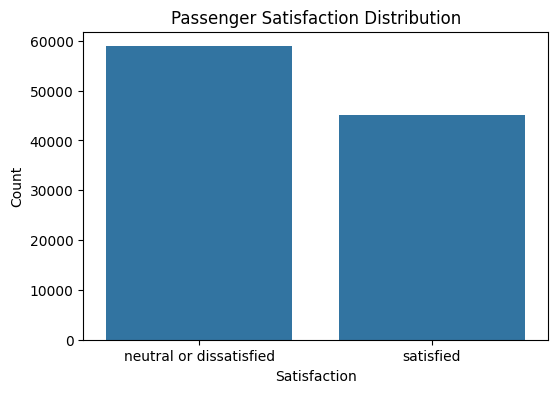

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=train, x="__FeatEng_target__")
plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.show()

# ***EDA***

<Axes: xlabel='Customer Type'>

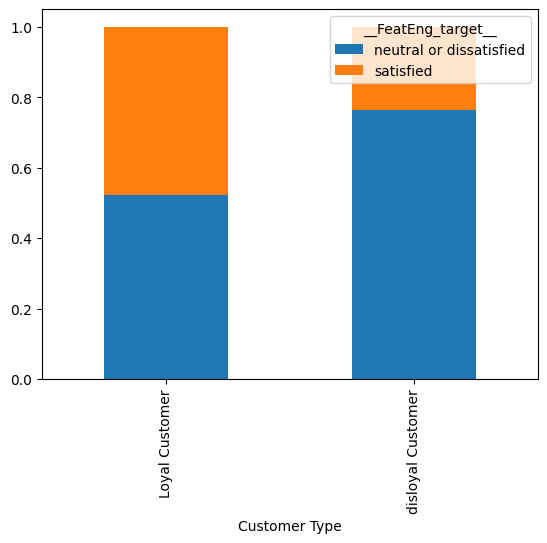

In [18]:
pd.crosstab(
    train["Customer Type"],
    train["__FeatEng_target__"],
    normalize="index"
).plot(kind="bar", stacked=True)

<Axes: xlabel='Class'>

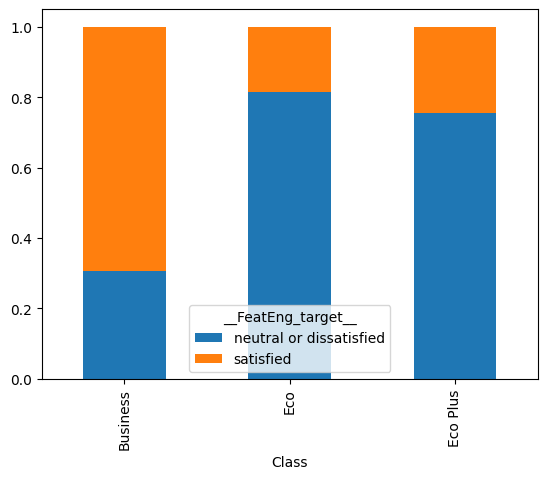

In [19]:
pd.crosstab(
    train["Class"],
    train["__FeatEng_target__"],
    normalize="index"
).plot(kind="bar", stacked=True)

<Axes: xlabel='Flight Distance', ylabel='Count'>

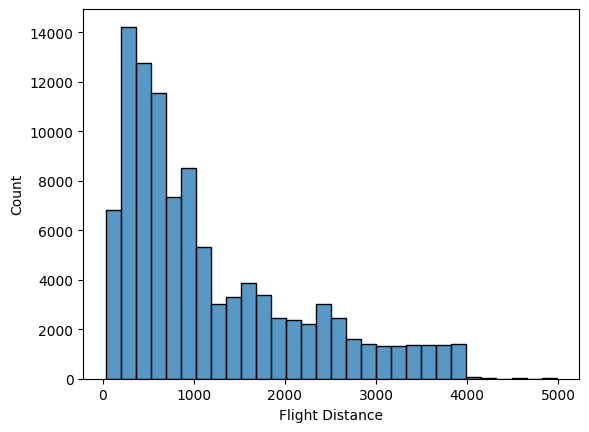

In [20]:
sns.histplot(train["Flight Distance"], bins=30)

<Axes: >

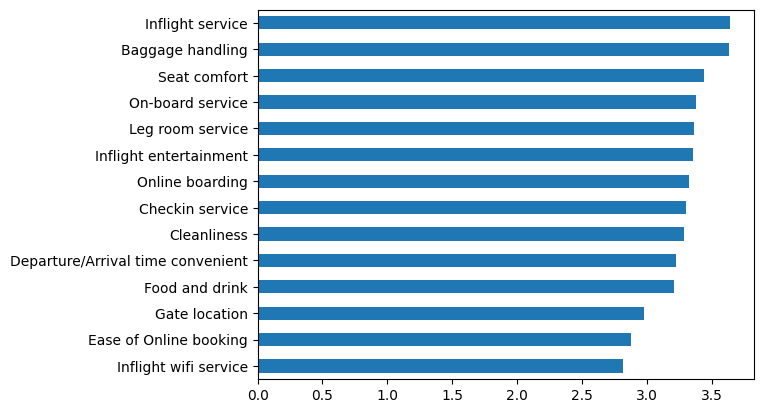

In [21]:
import numpy as np
rating_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

train[rating_cols].replace(0, np.nan).mean().sort_values().plot(kind="barh")

<Axes: >

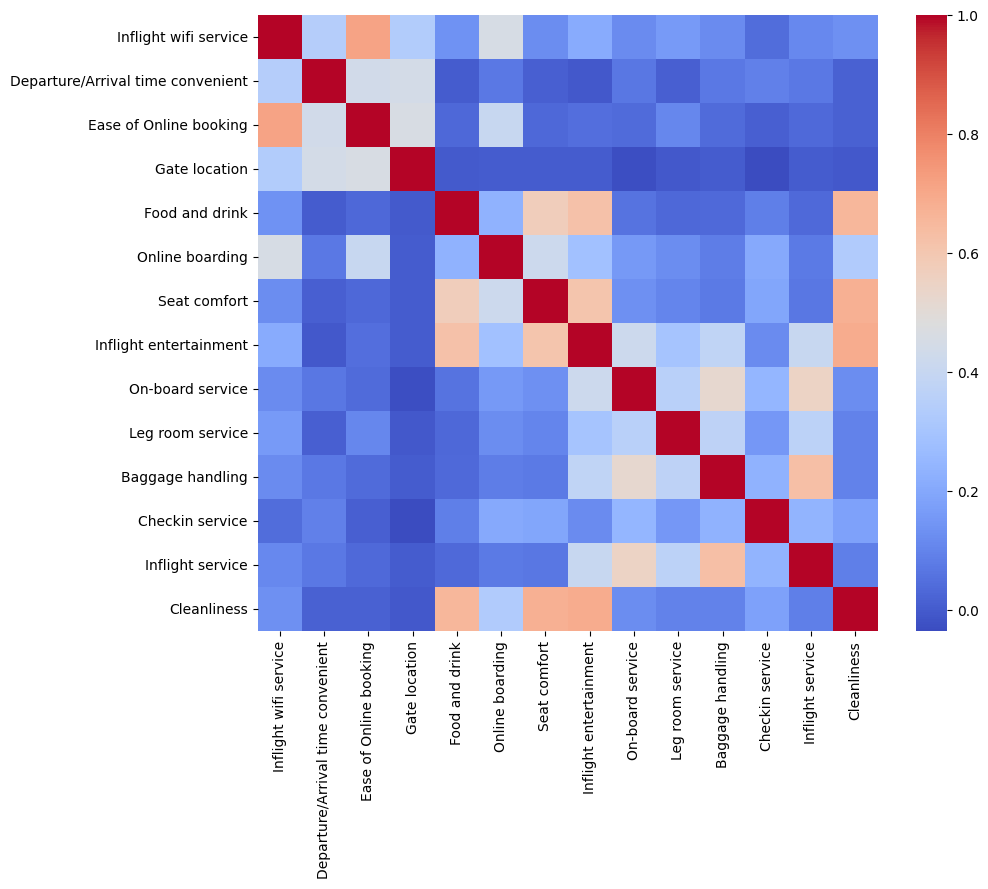

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(
    train[rating_cols].corr(),
    cmap="coolwarm"
)

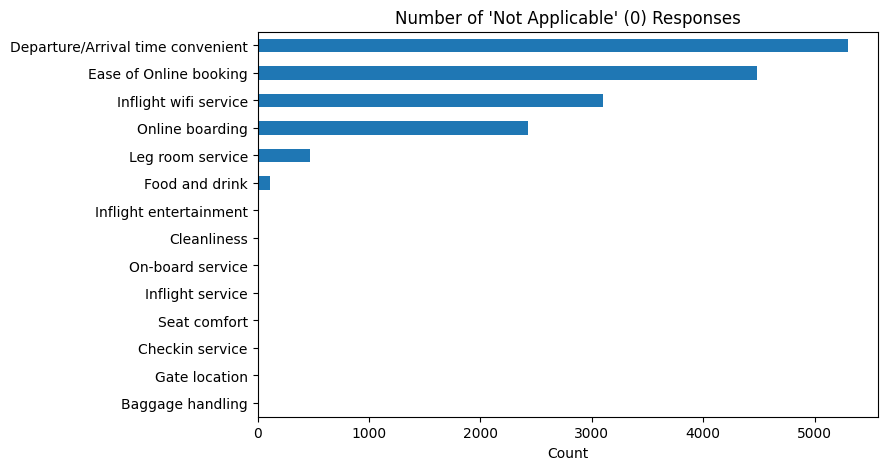

In [23]:
import numpy as np

zero_counts = (train[rating_cols] == 0).sum()

zero_counts.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Number of 'Not Applicable' (0) Responses")
plt.xlabel("Count")
plt.show()

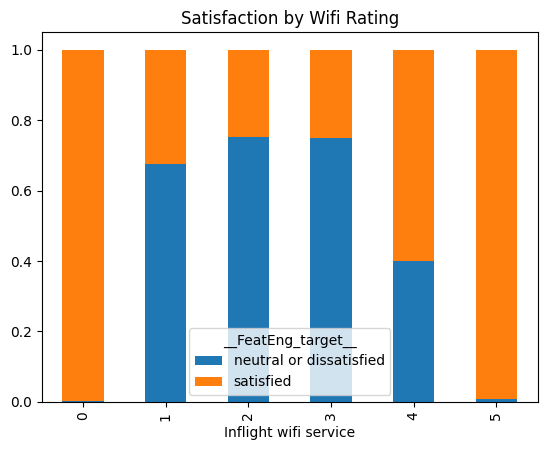

In [24]:
wifi_sat = pd.crosstab(
    train["Inflight wifi service"],
    train["__FeatEng_target__"],
    normalize="index"
)

wifi_sat.plot(kind="bar", stacked=True)

plt.title("Satisfaction by Wifi Rating")
plt.show()

# ***Feature Selection***

In [25]:
train_df = train.copy()

In [26]:
train_df  = train_df.drop(
    columns=[
        "Unnamed: 0.1",
        "__index_level_0__"
    ]
)

In [27]:
train_df[
    [
        "Departure Delay in Minutes",
        "Arrival Delay in Minutes"
    ]
].corr()

,Departure Delay in Minutes,Arrival Delay in Minutes
Departure Delay in Minutes,1.000000,0.965481
Arrival Delay in Minutes,0.965481,1.000000


In [28]:
who_features = [
    "Customer Type",
    "Type of Travel",
    "Class",
    "Flight Distance",
    "Age",
    "Gender"
]

In [29]:
rating_features = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

In [30]:
ops_features = [
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

# Model Training with classifications for Bsiness Analysis

In [31]:
train_df = train.copy()

train_df = train_df.drop(
    columns=[
        "Unnamed: 0.1",
        "__index_level_0__"
    ]
)

In [32]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

train_df["__FeatEng_target__"] = target_encoder.fit_transform(
    train_df["__FeatEng_target__"]
)

y = train_df["__FeatEng_target__"]

In [33]:
X = train_df.drop(columns=["__FeatEng_target__"])

X = pd.get_dummies(
    X,
    drop_first=True
)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import numpy as np

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Impute NaN values before fitting the model
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

X_train_scaled_imputed = imputer.fit_transform(X_train_scaled)
X_test_scaled_imputed = imputer.transform(X_test_scaled)

lr_model.fit(
    X_train_scaled_imputed,
    y_train
)

lr_pred = lr_model.predict(X_test_scaled_imputed)
lr_prob = lr_model.predict_proba(X_test_scaled_imputed)[:,1]

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [39]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    matthews_corrcoef
)

def evaluate(y_true,y_pred,y_prob):

    return [
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred),
        recall_score(y_true,y_pred),
        f1_score(y_true,y_pred),
        roc_auc_score(y_true,y_prob),
        log_loss(y_true,y_prob),
        matthews_corrcoef(y_true,y_pred)
    ]

In [41]:
import pandas as pd

results = pd.DataFrame(
    [
        evaluate(y_test,lr_pred,lr_prob),
        evaluate(y_test,rf_pred,rf_prob),
        evaluate(y_test,xgb_pred,xgb_prob)
    ],
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "Log Loss",
        "MCC"
    ],
    index=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
)

results

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Log Loss,MCC
Logistic Regression,0.876570,0.874593,0.834870,0.854270,0.925432,0.336181,0.747928
Random Forest,0.962514,0.972976,0.939589,0.955991,0.994118,0.105143,0.923788
XGBoost,0.961455,0.972254,0.937812,0.954723,0.994266,0.095953,0.921640


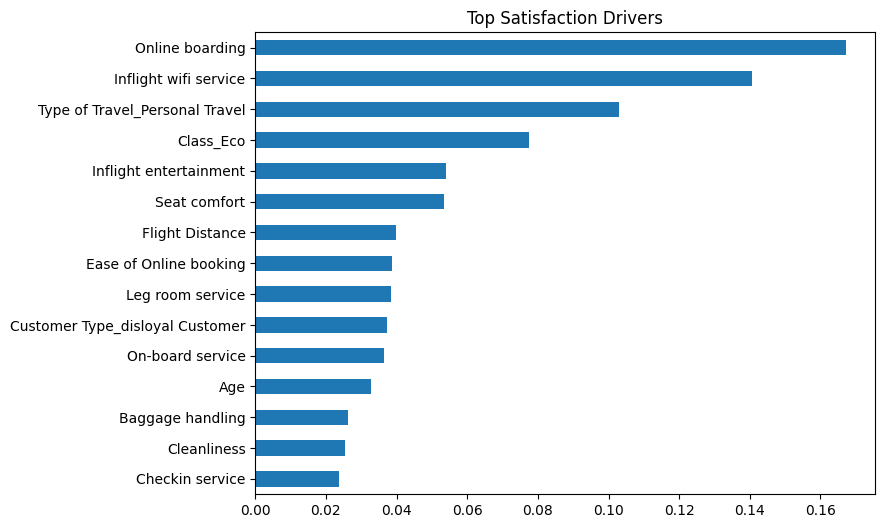

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

top15 = importance.nlargest(15)

top15.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Top Satisfaction Drivers")
plt.show()

# **Clustering**

In [43]:
rating_features = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

cluster_df = train_df[rating_features].copy()

In [44]:
import numpy as np

cluster_df = cluster_df.replace(0, np.nan)

cluster_df = cluster_df.fillna(
    cluster_df.median()
)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_df)

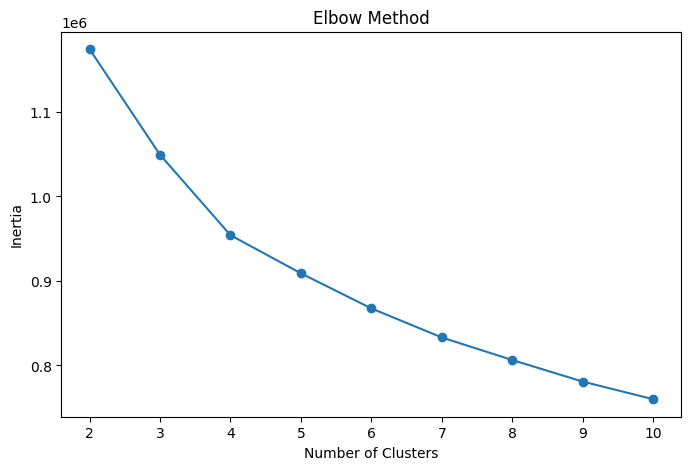

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [47]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [54]:
from sklearn.cluster import MiniBatchKMeans

mbk = MiniBatchKMeans(
    n_clusters=4,
    random_state=42
)

mbk_labels = mbk.fit_predict(X_scaled)

In [49]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

In [55]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

def evaluate_clustering(X, labels):
    return {
        "Silhouette Score": silhouette_score(X, labels),
        "Davies-Bouldin Index": davies_bouldin_score(X, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(X, labels)
    }

In [56]:
import pandas as pd

results = pd.DataFrame([
    evaluate_clustering(X_scaled, kmeans_labels),
    evaluate_clustering(X_scaled, mbk_labels),
    evaluate_clustering(X_scaled, gmm_labels)
],
index=[
    "KMeans",
    "MiniBatchKMeans",
    "GaussianMixture"
])

results

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
KMeans,0.144926,1.916065,18170.064532
MiniBatchKMeans,0.144814,1.914574,18160.072197
GaussianMixture,-0.003206,13.076103,1782.180140


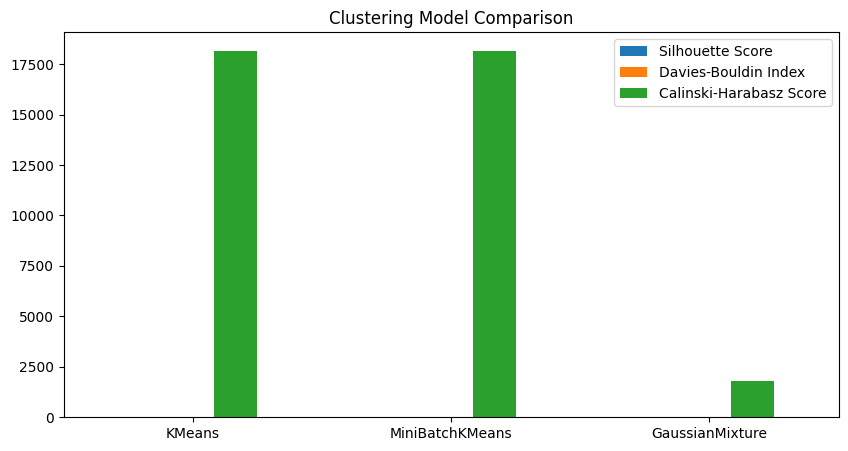

In [57]:
import matplotlib.pyplot as plt

results.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Clustering Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [58]:
best_labels = mbk_labels

In [59]:
train_df["Service_Cluster"] = best_labels

In [60]:
train_df["Service_Cluster"].value_counts()

,count
Service_Cluster,
1,29621
3,25824
0,24275
2,24184


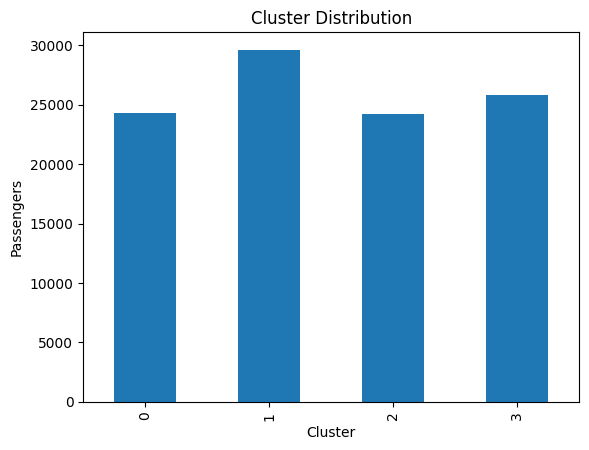

In [61]:
train_df["Service_Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Passengers")
plt.show()

In [62]:
cluster_profile = train_df.groupby(
    "Service_Cluster"
)[rating_features].mean().round(2)

cluster_profile

,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
Service_Cluster,,,,,,,,,,,,,,
0,4.17,4.13,4.14,4.02,3.70,4.08,4.02,4.12,3.92,3.83,4.10,3.63,4.11,3.86
1,2.12,2.43,2.01,2.21,3.81,3.45,4.16,4.34,4.11,3.86,4.27,3.73,4.29,4.03
2,2.32,3.08,2.54,3.00,1.72,2.26,1.82,1.91,3.22,3.25,3.68,3.03,3.70,1.69
3,2.46,2.76,2.52,2.86,3.43,3.17,3.59,2.87,2.19,2.41,2.41,2.76,2.39,3.39


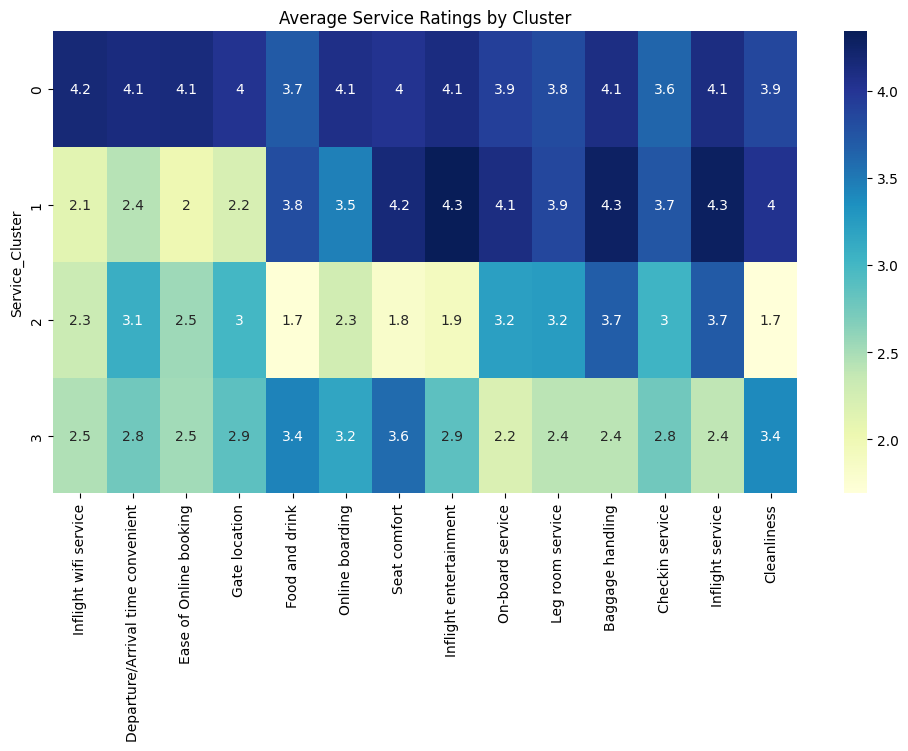

In [63]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Average Service Ratings by Cluster")
plt.show()

In [64]:
pd.crosstab(
    train_df["Service_Cluster"],
    train_df["__FeatEng_target__"],
    normalize="index"
) * 100

__FeatEng_target__,0,1
Service_Cluster,,
0,25.198764,74.801236
1,40.879781,59.120219
2,85.353953,14.646047
3,77.489932,22.510068


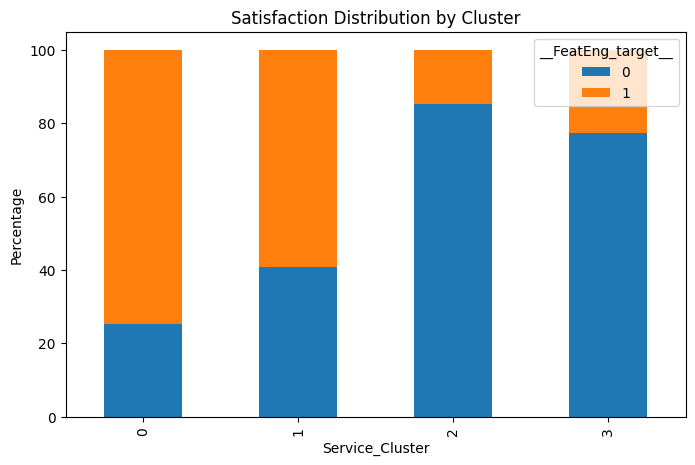

In [65]:
sat_cluster = pd.crosstab(
    train_df["Service_Cluster"],
    train_df["__FeatEng_target__"],
    normalize="index"
) * 100

sat_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Satisfaction Distribution by Cluster")
plt.ylabel("Percentage")
plt.show()

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

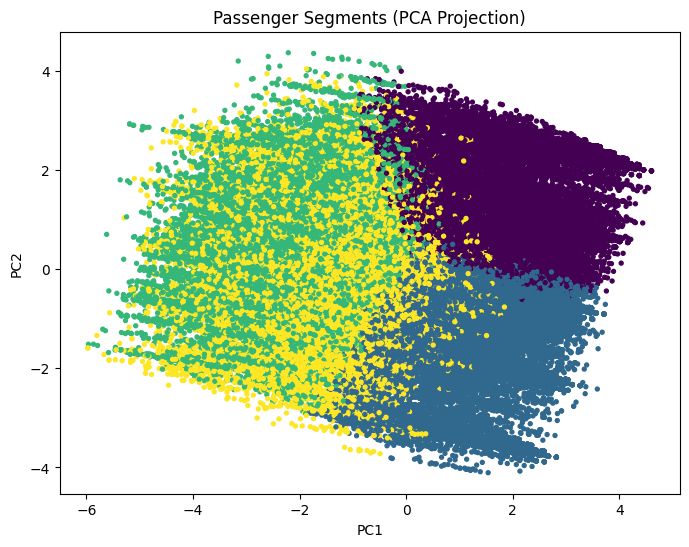

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_labels,
    cmap="viridis",
    s=8
)

plt.title("Passenger Segments (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [68]:
pca_full = PCA()

pca_full.fit(X_scaled)

cum_var = pca_full.explained_variance_ratio_.cumsum()

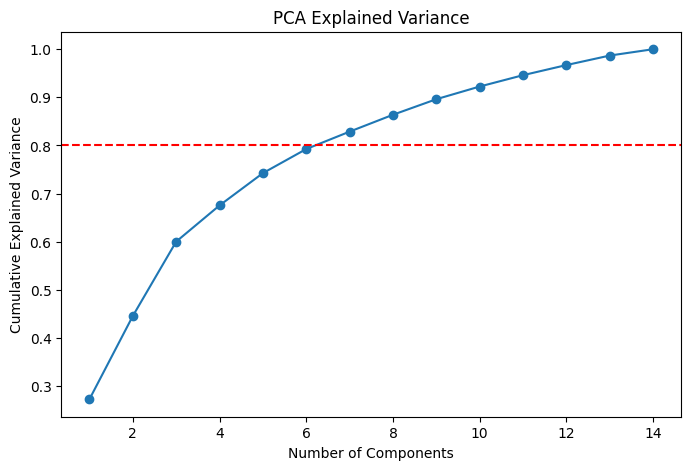

In [69]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.axhline(
    y=0.8,
    color='red',
    linestyle='--'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.show()

In [70]:
for cluster in sorted(train_df["Service_Cluster"].unique()):

    print("\nCluster", cluster)

    print(
        cluster_profile.loc[cluster]
        .sort_values()
        .head(3)
    )


Cluster 0
Checkin service     3.63
Food and drink      3.70
Leg room service    3.83
Name: 0, dtype: float64

Cluster 1
Ease of Online booking    2.01
Inflight wifi service     2.12
Gate location             2.21
Name: 1, dtype: float64

Cluster 2
Cleanliness       1.69
Food and drink    1.72
Seat comfort      1.82
Name: 2, dtype: float64

Cluster 3
On-board service    2.19
Inflight service    2.39
Leg room service    2.41
Name: 3, dtype: float64


In [71]:
cluster_profile.mean().sort_values()

,0
Inflight wifi service,2.7675
Ease of Online booking,2.8025
Gate location,3.0225
Departure/Arrival time convenient,3.1000
Food and drink,3.1650
Online boarding,3.2400
Cleanliness,3.2425
Checkin service,3.2875
Inflight entertainment,3.3100
Leg room service,3.3375


In [73]:
overall_service_gap = (
    train_df[rating_features]
    .mean()
    .sort_values()
)

overall_service_gap

,0
Inflight wifi service,2.729683
Ease of Online booking,2.756901
Gate location,2.976883
Departure/Arrival time convenient,3.060296
Food and drink,3.202129
Online boarding,3.250375
Cleanliness,3.286351
Checkin service,3.304290
Leg room service,3.351055
Inflight entertainment,3.358158


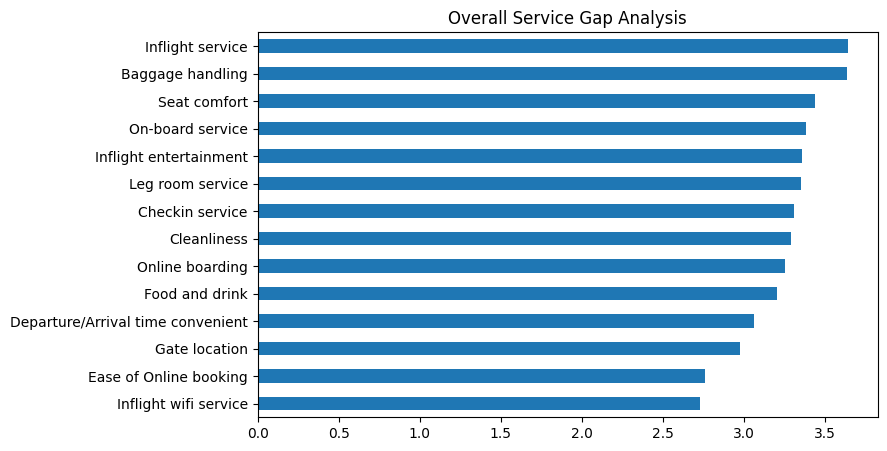

In [74]:
overall_service_gap.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Overall Service Gap Analysis")
plt.show()

# Final ₹500 Crore Investment Recommendation
**Priority 1 — Wifi Upgrade**

Reason:

Worst-rated service overall.
Major pain point in Cluster 1.
Affects many passengers.

**Priority 2 — New Mobile App & Online Booking**

Reason:
Online booking is consistently weak.
Directly impacts Digital Frustrated Travelers.

**Priority 3 — Seat Comfort + Cleanliness Upgrade**

Reason:
Critical issue for Cluster 2.
Most dissatisfied segment.

**Priority 4 — Service Quality Training**

Reason:

Cluster 3 dissatisfaction is driven by service interactions.

Priority 5 — Food Improvement **bold text**

Reason:
Moderate issue across multiple clusters.